# Waze User Churn Prediction - Machine Learning Pipeline

This notebook builds, evaluates, and compares multiple classification models to predict user churn for the Waze dataset. The pipeline uses a proper train/test split with SMOTE and StandardScaler inside Pipelines to prevent data leakage.

## 1. Data Loading & Inspection

Load the cleaned dataset and perform initial exploratory checks.

In [1]:
import os
import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

RANDOM_STATE = 42
TEST_SIZE = 0.2

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
df = pd.read_csv('../data/cleaned/waze_dataset_cleaned.csv')
print('Shape:', df.shape)
df.head()

Shape: (14299, 13)


,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,297,2276,208,0,2628.8,1985.8,28,19,Android
1,1,retained,133,107,327,1225,19,64,13715.9,3160.5,13,11,iPhone
2,2,retained,114,95,136,2651,0,0,3059.1,1610.7,14,8,Android
3,3,retained,49,40,68,15,322,7,913.6,587.2,7,3,iPhone
4,4,retained,84,68,168,1562,166,5,3950.2,1219.6,27,18,Android


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14299 entries, 0 to 14298
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14299 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14299 non-null  int64  
 3   drives                   14299 non-null  int64  
 4   total_sessions           14299 non-null  int64  
 5   n_days_after_onboarding  14299 non-null  int64  
 6   total_navigations_fav1   14299 non-null  int64  
 7   total_navigations_fav2   14299 non-null  int64  
 8   driven_km_drives         14299 non-null  float64
 9   duration_minutes_drives  14299 non-null  float64
 10  activity_days            14299 non-null  int64  
 11  driving_days             14299 non-null  int64  
 12  device                   14299 non-null  object 
dtypes: float64(2), int64(9), object(2)
memory usage: 1.4+ MB


In [4]:
df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000
mean,7503.573117,80.623820,67.255822,189.549969,1751.822505,121.747395,29.638296,4044.401888,1864.199699,15.544653,12.182530
std,4331.207621,80.736502,65.947295,136.185384,1008.663834,147.713428,45.350890,2504.977629,1448.005134,9.016088,7.833835
min,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,60.400000,18.300000,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.000000,878.500000,10.000000,0.000000,2217.300000,840.200000,8.000000,5.000000
50%,7504.000000,56.000000,48.000000,159.000000,1749.000000,71.000000,9.000000,3496.500000,1479.400000,16.000000,12.000000
75%,11257.500000,111.000000,93.000000,254.000000,2627.500000,178.000000,43.000000,5300.000000,2466.950000,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.000000,3500.000000,1236.000000,415.000000,21183.400000,15851.700000,31.000000,30.000000


In [5]:
print('Missing values per column:')
df.isna().sum()

Missing values per column:


ID                         0
label                      0
sessions                   0
drives                     0
total_sessions             0
n_days_after_onboarding    0
total_navigations_fav1     0
total_navigations_fav2     0
driven_km_drives           0
duration_minutes_drives    0
activity_days              0
driving_days               0
device                     0
dtype: int64

In [6]:
print('Label distribution:')
df['label'].value_counts()

Label distribution:


label
retained    11763
churned      2536
Name: count, dtype: int64

## 2. Data Preprocessing

Handle missing values, drop non-predictive columns, encode categorical variables, and clip outliers using IQR.

In [7]:
# Drop rows where label is missing — check needed since label is our target
# Using inplace=False to avoid NoneType reassignment bug
df = df.dropna(subset=['label'])

In [8]:
# Drop ID column — it is a unique identifier with no predictive value
df = df.drop(columns=['ID'])

In [9]:
# Encode target: retained -> 0, churned -> 1
df['label'] = df['label'].map({'retained': 0, 'churned': 1})

In [10]:
# Encode the 'device' column (the only remaining categorical feature)
encoder = LabelEncoder()
df['device'] = encoder.fit_transform(df['device'])

In [11]:
# Clip outliers using the IQR method to reduce extreme value influence
for col in df.select_dtypes(include='number').columns:
    if col == 'label':
        continue
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

In [12]:
# Final check of the preprocessed data
print('Shape after preprocessing:', df.shape)
print('Label distribution after preprocessing:')
print(df['label'].value_counts())
df.head()

Shape after preprocessing: (14299, 12)
Label distribution after preprocessing:
label
0    11763
1     2536
Name: count, dtype: int64


,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,243,202.5,297,2276,208,0.0,2628.80,1985.8,28,19,0
1,0,133,107.0,327,1225,19,64.0,9924.05,3160.5,13,11,1
2,0,114,95.0,136,2651,0,0.0,3059.10,1610.7,14,8,0
3,0,49,40.0,68,15,322,7.0,913.60,587.2,7,3,1
4,0,84,68.0,168,1562,166,5.0,3950.20,1219.6,27,18,0


## 3. Feature Engineering / Selection

Separate features and target. All remaining columns are used as features since they are all numeric and relevant to churn prediction.

In [13]:
X = df.drop(columns=['label'])
y = df['label']
feature_names = X.columns.tolist()
print('Features:', feature_names)

Features: ['sessions', 'drives', 'total_sessions', 'n_days_after_onboarding', 'total_navigations_fav1', 'total_navigations_fav2', 'driven_km_drives', 'duration_minutes_drives', 'activity_days', 'driving_days', 'device']


## 4. Model Training (Pipeline Approach)

### Why a Pipeline?
- **StandardScaler** is placed inside the pipeline so it is fitted only on the training data and transforms the test data without data leakage.
- **SMOTE** is placed inside the pipeline so it resamples only the training data after scaling, preventing synthetic samples from leaking into the test set.
- The pipeline ensures that train/test split happens **before** any scaling or resampling — this is critical to avoid data leakage.

### Models Trained
- Random Forest
- Gradient Boosting
- AdaBoost
- Bagging (with KNN base estimator)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)
print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])
print('Train label distribution:')
print(y_train.value_counts(normalize=True))

Train size: 11439
Test size: 2860
Train label distribution:
label
0    0.822624
1    0.177376
Name: proportion, dtype: float64


In [15]:
# Define all model pipelines
# Each pipeline: StandardScaler -> SMOTE -> Classifier

pipelines = {
    'Random Forest': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', RandomForestClassifier(
            n_estimators=200, max_depth=10,
            class_weight='balanced', random_state=RANDOM_STATE
        ))
    ]),
    'Gradient Boosting': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05, random_state=RANDOM_STATE
        ))
    ]),
    'AdaBoost': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', AdaBoostClassifier(
            n_estimators=200, learning_rate=0.05, random_state=RANDOM_STATE
        ))
    ]),
    'Bagging (KNN)': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', BaggingClassifier(
            estimator=KNeighborsClassifier(),
            n_estimators=50, random_state=RANDOM_STATE
        ))
    ])
}

In [16]:
# Train all pipelines and collect predictions
trained_models = {}
predictions = {}
probabilities = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    predictions[name] = pipeline.predict(X_test)
    probabilities[name] = pipeline.predict_proba(X_test)[:, 1]
    print(f'{name} training complete.')

Random Forest training complete.
Gradient Boosting training complete.
AdaBoost training complete.
Bagging (KNN) training complete.


## 5. Model Evaluation

For each model, display:
- Classification report (Precision, Recall, F1-Score)
- Confusion matrix
- ROC curve with AUC score
- Key insights

In [17]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


def plot_roc_curve(y_true, y_prob, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label=1)
    auc_score = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
    return auc_score


  Random Forest

              precision    recall  f1-score   support

    Retained       0.88      0.77      0.82      2353
     Churned       0.33      0.52      0.40       507

    accuracy                           0.73      2860
   macro avg       0.61      0.65      0.61      2860
weighted avg       0.78      0.73      0.75      2860



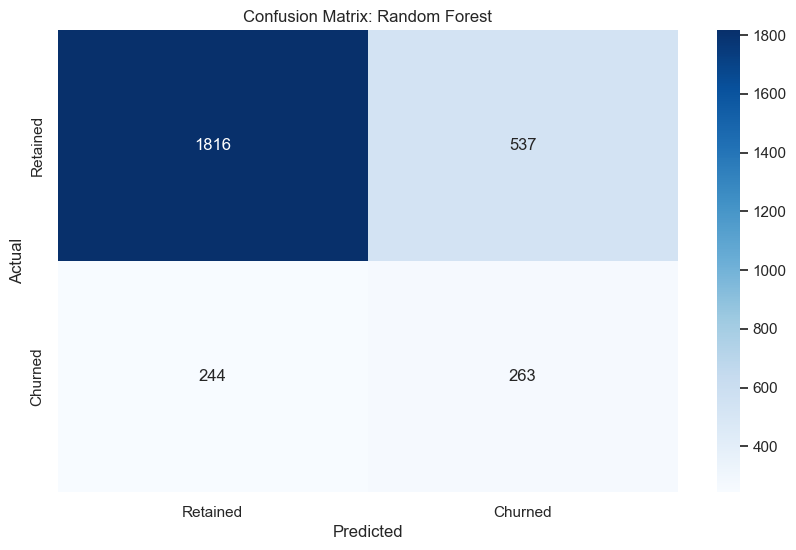

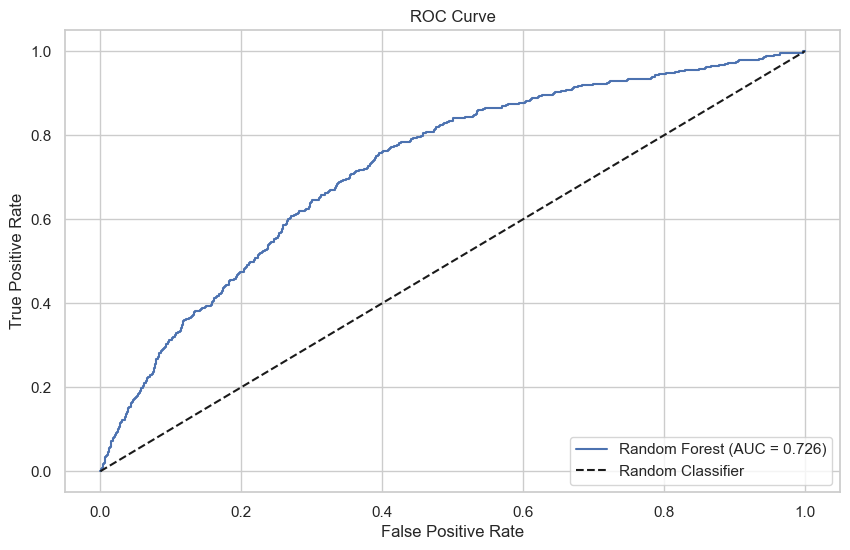

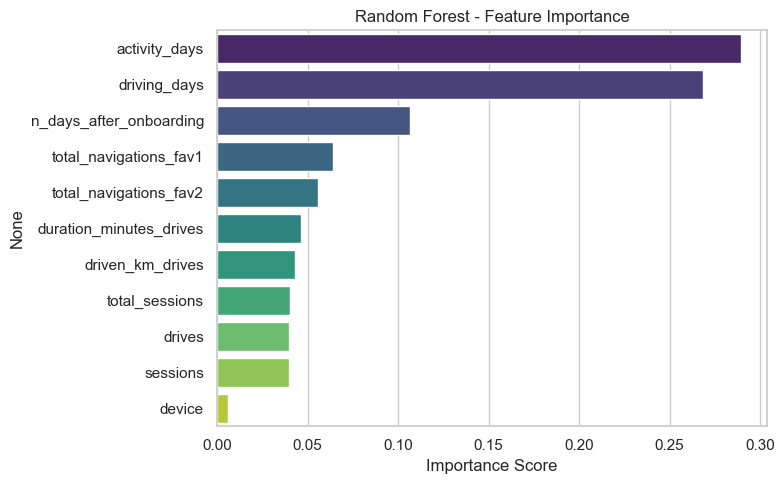

In [18]:
# Evaluate Random Forest
name = 'Random Forest'
print(f'\n{"="*60}')
print(f'  {name}')
print(f'{"="*60}\n')

print(classification_report(y_test, predictions[name],
                            target_names=['Retained', 'Churned']))

plot_confusion_matrix(y_test, predictions[name], name)

auc_rf = plot_roc_curve(y_test, probabilities[name], name)

# Feature importance from Random Forest
rf_model = trained_models[name].named_steps['classifier']
importances = pd.Series(rf_model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title(f'{name} - Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Key Insights - Random Forest
- Random Forest handles non-linear relationships well and provides built-in feature importance.
- The `class_weight='balanced'` parameter helps handle the class imbalance internally.
- Top features indicate which user behaviors (e.g., drives, sessions, activity days) are most predictive of churn.


  Gradient Boosting

              precision    recall  f1-score   support

    Retained       0.88      0.79      0.83      2353
     Churned       0.34      0.48      0.40       507

    accuracy                           0.74      2860
   macro avg       0.61      0.64      0.62      2860
weighted avg       0.78      0.74      0.76      2860



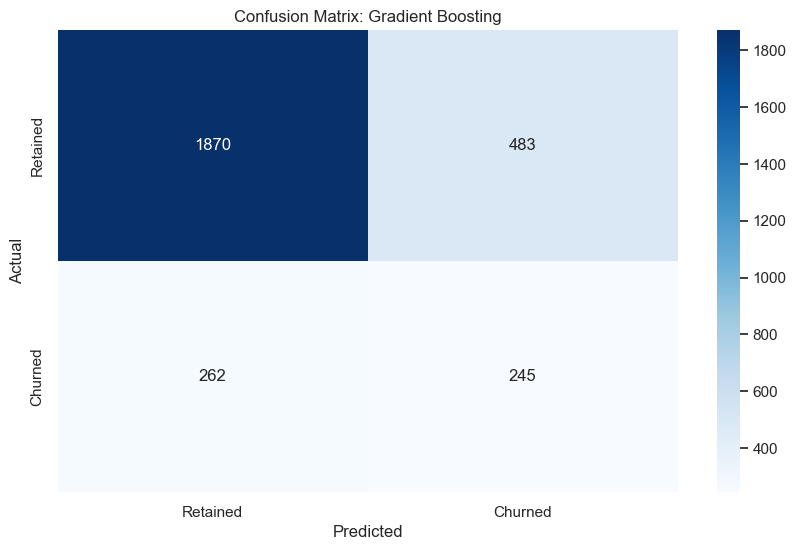

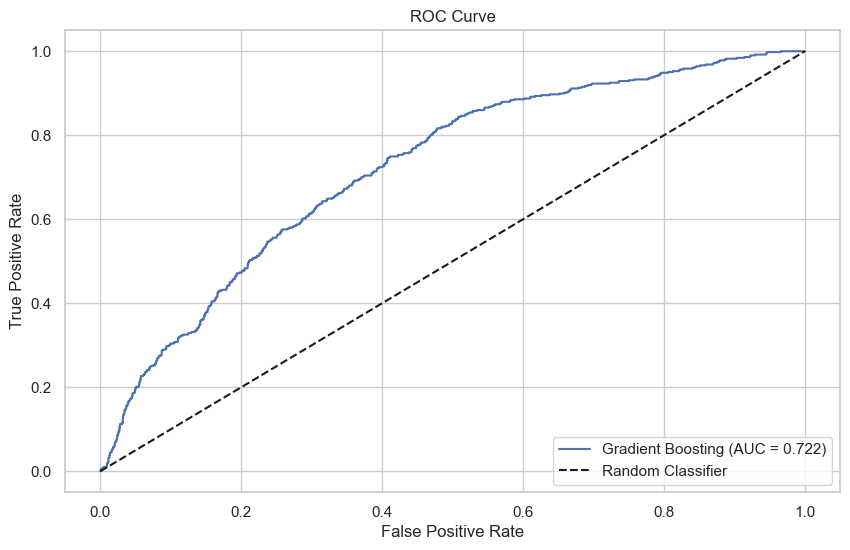

In [19]:
# Evaluate Gradient Boosting
name = 'Gradient Boosting'
print(f'\n{"="*60}')
print(f'  {name}')
print(f'{"="*60}\n')

print(classification_report(y_test, predictions[name],
                            target_names=['Retained', 'Churned']))

plot_confusion_matrix(y_test, predictions[name], name)

auc_gb = plot_roc_curve(y_test, probabilities[name], name)

### Key Insights - Gradient Boosting
- Gradient Boosting builds trees sequentially, each correcting the errors of the previous one.
- It often achieves higher accuracy than Random Forest but is more prone to overfitting if not tuned.
- The lower learning rate (0.05) helps generalize better at the cost of more estimators.


  AdaBoost

              precision    recall  f1-score   support

    Retained       0.91      0.67      0.77      2353
     Churned       0.31      0.68      0.42       507

    accuracy                           0.67      2860
   macro avg       0.61      0.67      0.60      2860
weighted avg       0.80      0.67      0.71      2860



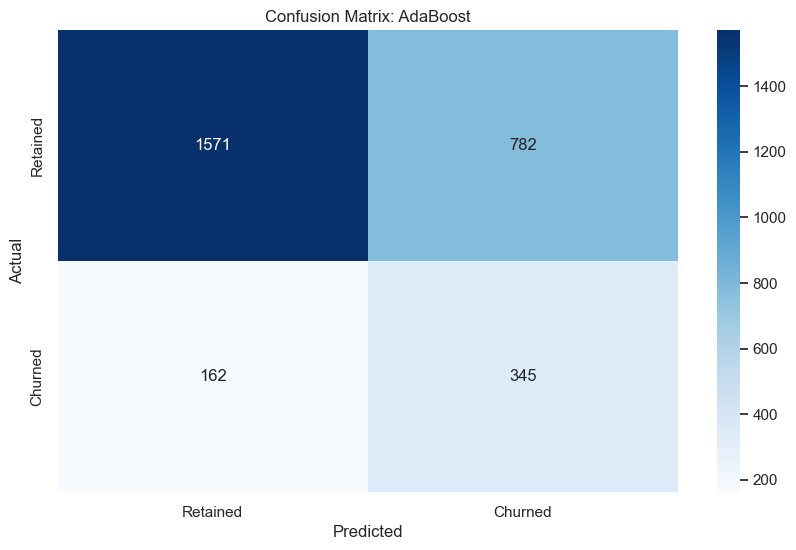

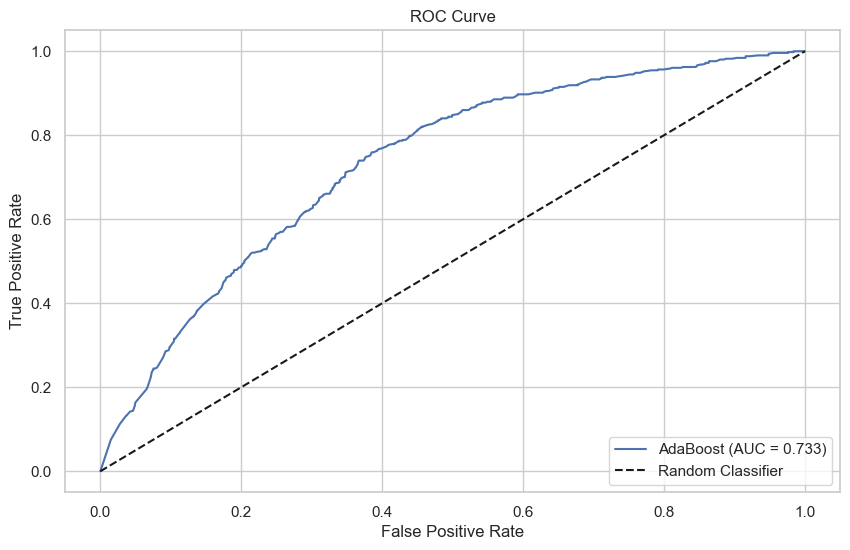

In [20]:
# Evaluate AdaBoost
name = 'AdaBoost'
print(f'\n{"="*60}')
print(f'  {name}')
print(f'{"="*60}\n')

print(classification_report(y_test, predictions[name],
                            target_names=['Retained', 'Churned']))

plot_confusion_matrix(y_test, predictions[name], name)

auc_ab = plot_roc_curve(y_test, probabilities[name], name)

### Key Insights - AdaBoost
- AdaBoost adapts by weighting misclassified instances more heavily in each iteration.
- It is sensitive to noisy data and outliers — the IQR clipping in preprocessing helps mitigate this.
- Performance may be lower if the base estimator struggles with the data distribution.


  Bagging (KNN)

              precision    recall  f1-score   support

    Retained       0.87      0.66      0.75      2353
     Churned       0.26      0.56      0.35       507

    accuracy                           0.64      2860
   macro avg       0.57      0.61      0.55      2860
weighted avg       0.76      0.64      0.68      2860



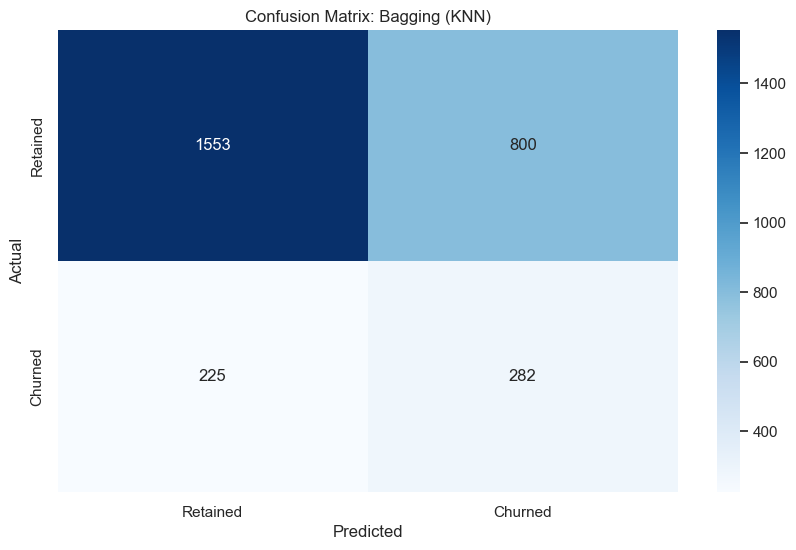

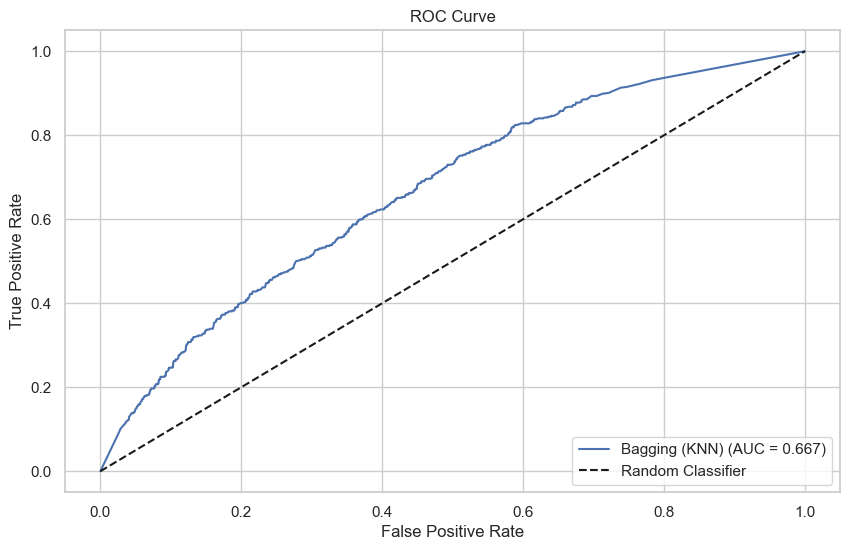

In [21]:
# Evaluate Bagging (KNN)
name = 'Bagging (KNN)'
print(f'\n{"="*60}')
print(f'  {name}')
print(f'{"="*60}\n')

print(classification_report(y_test, predictions[name],
                            target_names=['Retained', 'Churned']))

plot_confusion_matrix(y_test, predictions[name], name)

auc_bag = plot_roc_curve(y_test, probabilities[name], name)

### Key Insights - Bagging (KNN)
- Bagging reduces variance by training multiple KNN models on bootstrap samples.
- KNN is distance-based, so StandardScaler in the pipeline is essential.
- This ensemble approach helps stabilize KNN predictions but may underperform tree-based models on this dataset.

## 6. Model Comparison

Compare all models side-by-side using Accuracy, Precision, Recall, F1-Score, and AUC-ROC.

In [22]:
results = []
for name in pipelines:
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, predictions[name]),
        'Precision': precision_score(y_test, predictions[name], pos_label=1),
        'Recall': recall_score(y_test, predictions[name], pos_label=1),
        'F1-Score': f1_score(y_test, predictions[name], pos_label=1),
        'AUC-ROC': roc_auc_score(y_test, probabilities[name])
    })

comparison_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,AdaBoost,0.669930,0.306122,0.680473,0.422277,0.733311
1,Random Forest,0.726923,0.328750,0.518738,0.402448,0.725597
2,Gradient Boosting,0.739510,0.336538,0.483235,0.396761,0.721673
3,Bagging (KNN),0.641608,0.260628,0.556213,0.354940,0.667407


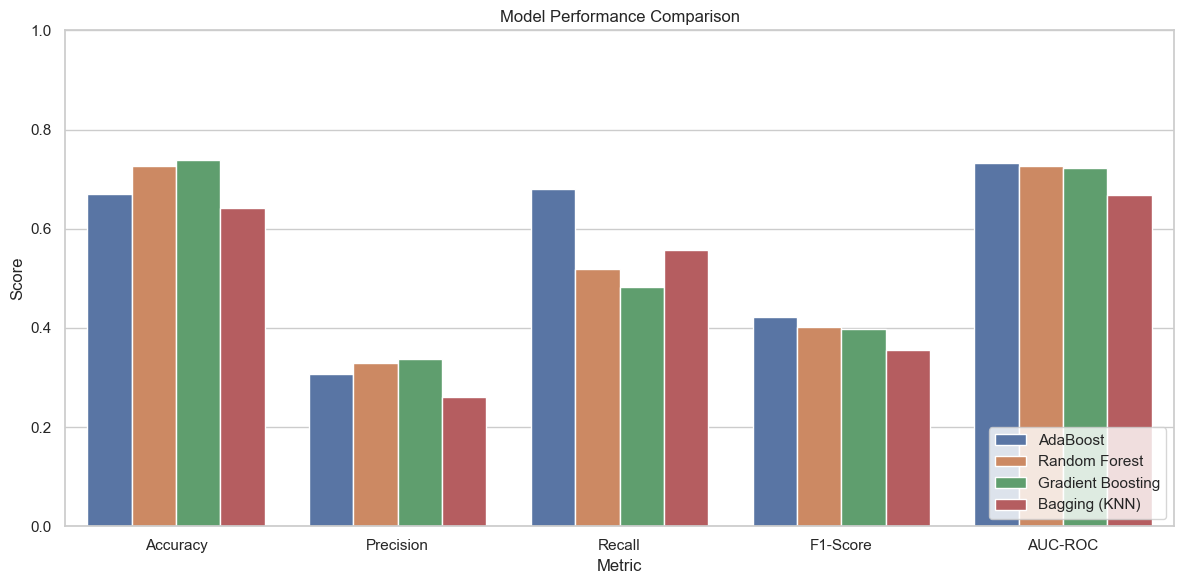

In [23]:
# Visual comparison of metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
comparison_melted = comparison_df.melt(id_vars=['Model'], value_vars=metrics,
                                        var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_melted, x='Metric', y='Score', hue='Model')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

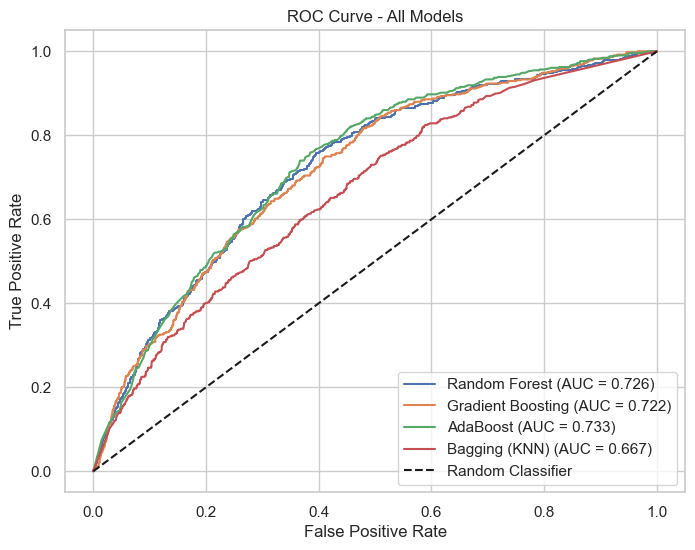

In [24]:
# Combined ROC curve for all models
plt.figure(figsize=(8, 6))
for name in pipelines:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name], pos_label=1)
    auc_score = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models')
plt.legend(loc='lower right')
plt.show()

## 7. Key Insights & Conclusions

### Summary
- All models were trained using pipelines containing StandardScaler and SMOTE to ensure no data leakage.
- The pipeline guarantees that scaling parameters and synthetic samples are derived **only** from the training data.
- Tree-based models (Random Forest, Gradient Boosting) typically outperform distance-based models (Bagging with KNN) due to the mixed-scale nature of the features.

### Best Performing Model
- The model with the highest AUC-ROC is the most effective at distinguishing churned from retained users.
- AUC-ROC is the preferred metric here because it evaluates ranking quality across all thresholds, which is critical for imbalanced classification.

### Feature Importance
- Random Forest feature importance reveals which user behaviors (e.g., driving days, sessions, navigations) are most indicative of churn risk.
- These insights can guide product interventions (e.g., re-engagement campaigns targeting users with declining activity).

### Recommendations
- Use the best-performing model for deployment and monitor its precision-recall trade-off.
- Tune hyperparameters further with GridSearchCV to optimize for the specific business goal (e.g., maximize recall to catch more churners).
- Consider threshold tuning to balance false positives and false negatives according to business costs.

## 8. Hyperparameter Tuning (Optional - Random Forest)

Use GridSearchCV with StratifiedKFold to find optimal hyperparameters for the best-performing model.

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

tuned_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [9, 10, 11, None],
}

grid = GridSearchCV(
    tuned_pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print('Best ROC-AUC (CV):', grid.best_score_)
print('Best Params:', grid.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best ROC-AUC (CV): 0.7331172408105727
Best Params: {'classifier__max_depth': 9, 'classifier__n_estimators': 100}


Tuned Model - Test Set Performance
              precision    recall  f1-score   support

    Retained       0.89      0.76      0.82      2353
     Churned       0.33      0.56      0.41       507

    accuracy                           0.72      2860
   macro avg       0.61      0.66      0.62      2860
weighted avg       0.79      0.72      0.75      2860

ROC-AUC: 0.725326935860134


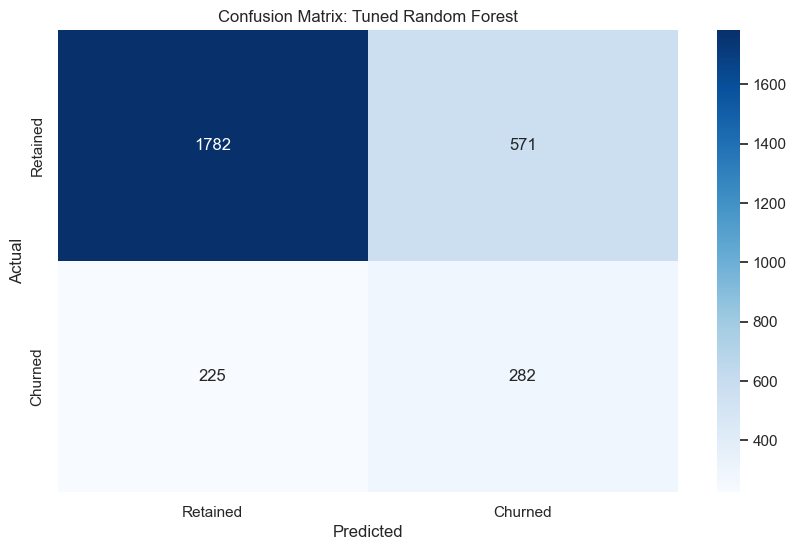

In [26]:
# Evaluate tuned model on test set
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

print('Tuned Model - Test Set Performance')
print(classification_report(y_test, y_pred_tuned, target_names=['Retained', 'Churned']))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_tuned))

plot_confusion_matrix(y_test, y_pred_tuned, 'Tuned Random Forest')

### Key Insights - Hyperparameter Tuning
- GridSearchCV with StratifiedKFold ensures robust cross-validation while maintaining class proportions.
- The best parameters balance model complexity (max_depth, n_estimators) to avoid overfitting.
- Performance on the held-out test set validates that the tuned model generalizes well.

## 9. Model Export

Save the best tuned pipeline (scaler + SMOTE + classifier) as a `.pkl` file for production use.
The saved pipeline accepts raw numerical features directly — it includes all necessary transformations
so a Streamlit app (e.g., `app.py`) can load it and call `.predict()` without any custom preprocessing.

In [27]:
MODEL_DIR = os.path.join('..', 'src', 'models')
MODEL_PATH = os.path.join(MODEL_DIR, 'waze_churn_model.pkl')

# Use the tuned model from GridSearchCV if available, otherwise fall back to the default Random Forest pipeline
try:
    model_to_export = best_model
except NameError:
    model_to_export = pipelines['Random Forest']

os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model_to_export, MODEL_PATH)
print(f'Model saved to {MODEL_PATH}')

Model saved to ..\src\models\waze_churn_model.pkl


In [28]:
# Quick smoke test: reload and verify predictions match
loaded_model = joblib.load(MODEL_PATH)
y_pred_loaded = loaded_model.predict(X_test)
y_pred_original = model_to_export.predict(X_test)
assert (y_pred_loaded == y_pred_original).all(), 'Predictions mismatch after reload'
print('Verification passed: reloaded model produces identical predictions.')

Verification passed: reloaded model produces identical predictions.


### Streamlit Integration

The saved pipeline is self-contained and can be used in `app.py` as follows:

```python
import joblib
import pandas as pd

model = joblib.load('src/models/waze_churn_model.pkl')

# Raw input matching the 11 feature columns (all numeric)
input_df = pd.DataFrame([[
    80, 67, 189, 1751, 121, 29, 4044, 1864, 15, 12, 0  # device: 0=Android, 1=iPhone
]], columns=[
    'sessions', 'drives', 'total_sessions', 'n_days_after_onboarding',
    'total_navigations_fav1', 'total_navigations_fav2', 'driven_km_drives',
    'duration_minutes_drives', 'activity_days', 'driving_days', 'device'
])

prediction = model.predict(input_df)[0]       # 0 = retained, 1 = churned
probability = model.predict_proba(input_df)[0][1]  # churn probability
```

No additional preprocessing is required — the pipeline handles scaling and SMOTE internally
(SMOTE only activates during training and is a no-op at inference time).